In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import pandas as pd

df = pd.read_json(
    "../data/raw/ember2018/train_features_2.jsonl",
    lines=True
)

print(df.shape)
df.head()

(127891, 14)


,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
0,cc0f79eea5ce5f72f8d7dd7e1ec4929d3ecb911683f5b0...,1ad30eb79ffc6fdb15a86e5ea00362da,2018-03,0,,"[6555, 413, 125, 168, 146, 111, 228, 64, 70, 7...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 269, 'avlength': 22.49814126394...","{'size': 23360, 'vsize': 40960, 'has_debug': 0...","{'coff': {'timestamp': 1522107473, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorDllMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
1,972a19b0dc047f482972e513446d3735ea7d41aadaa57e...,8860fecf9a64e193bfde8808889f7e48,2018-03,1,vittalia,"[64015, 2067, 1309, 1337, 1303, 1092, 1820, 96...","[14336, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 1177, 'avlength': 9.99575191163...","{'size': 359816, 'vsize': 516096, 'has_debug':...","{'coff': {'timestamp': 1438656236, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['SearchPathA', 'GetShortPath...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
2,d0341e9f3c69b58f7f327c9a6a137bfef668161ac03c3c...,52b883da80329adcc96836d4441f41f0,2018-03,-1,high,"[3913, 1206, 1077, 1087, 1127, 1071, 1126, 110...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 1351, 'avlength': 7.16210214655...","{'size': 269312, 'vsize': 294912, 'has_debug':...","{'coff': {'timestamp': 1509457220, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorExeMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
3,3839553ffec4ad25b5768f17bf98c9ba2d4f24423a1d4d...,0de5945a88c51d51e4eb81047d23c7dc,2018-03,-1,fareit,"[7664, 2436, 2324, 2301, 2249, 2139, 2244, 228...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 3625, 'avlength': 7.09075862068...","{'size': 837632, 'vsize': 860160, 'has_debug':...","{'coff': {'timestamp': 1412313165, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...",{'mscoree.dll': ['_CorExeMain']},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
4,2660a31e72550d7abef5350f2631bc35551cb4ed8ffab1...,ac0ad6071d341f3c663dbc20f542b6fa,2018-03,-1,,"[43155, 10638, 9850, 9859, 10241, 9690, 9910, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 11734, 'avlength': 5.6167547298...","{'size': 2553856, 'vsize': 10047488, 'has_debu...","{'coff': {'timestamp': 708992537, 'machine': '...","{'entry': 'CODE', 'sections': [{'name': 'CODE'...","{'kernel32.dll': ['LoadLibraryA', 'GetProcAddr...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [3]:
df.tail()

,sha256,md5,appeared,label,avclass,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories
127886,d86def8bb9c413eb0ce3290a5efefa91b611a3674951d0...,b967f30083f529a0a756376f36b8e98c,2018-04,1,scar,"[121757, 3576, 2166, 2890, 2764, 1874, 1796, 1...","[26577, 4099, 3, 1, 6, 3, 2, 2, 2, 2052, 2049,...","{'numstrings': 2401, 'avlength': 12.5914202415...","{'size': 583104, 'vsize': 131072, 'has_debug':...","{'coff': {'timestamp': 1360036987, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['GetCurrentThread', 'Virtual...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
127887,985c9612f1863ec55de3c10f7b48691761156e08755936...,5bd8a4e7220ee47d506e85da4555927c,2018-04,0,,"[370115, 29459, 32303, 33852, 48405, 19978, 31...","[28672, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","{'numstrings': 19821, 'avlength': 7.1927753392...","{'size': 5037624, 'vsize': 5050368, 'has_debug...","{'coff': {'timestamp': 1521598101, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'VERSION.dll': ['GetFileVersionInfoSizeW', 'V...","[CanInstallBrowser, CanInstallCustomProduct, C...","[{'name': 'EXPORT_TABLE', 'size': 3806, 'virtu..."
127888,46a00770e698d0c9edc0a2c76145a946006b0f010b48ad...,b0bedba720286af3bbeceaa8901550f7,2018-04,0,,"[1774, 18, 16, 19, 5, 33, 7, 10, 19, 4, 23, 8,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 75, 'avlength': 29.093333333333...","{'size': 5792, 'vsize': 5792, 'has_debug': 1, ...","{'coff': {'timestamp': 0, 'machine': 'AMD64', ...","{'entry': '.text', 'sections': [{'name': '.tex...",{},[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."
127889,31197dc6a11f53310cf25693f25a85c6fc063a2424a7a5...,cdd6f1e492c0779470cf3ff001870ea4,2018-04,0,,"[29460, 339, 357, 147, 142, 47, 44, 245, 263, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 21, 'avlength': 17.238095238095...","{'size': 51712, 'vsize': 69632, 'has_debug': 1...","{'coff': {'timestamp': 1470640543, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['QueryPerformanceCounter', '...",[DllInitialize],"[{'name': 'EXPORT_TABLE', 'size': 76, 'virtual..."
127890,7ee58aeb407137527a0965a157bef8501031c7849219e5...,20b880c8c3eff4a3ec5d34f58b9029a4,2018-04,0,,"[13630, 1170, 499, 512, 703, 333, 246, 294, 97...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'numstrings': 411, 'avlength': 12.28223844282...","{'size': 73216, 'vsize': 90112, 'has_debug': 1...","{'coff': {'timestamp': 1150202767, 'machine': ...","{'entry': '.text', 'sections': [{'name': '.tex...","{'KERNEL32.dll': ['CompareStringA', 'GetWindow...",[],"[{'name': 'EXPORT_TABLE', 'size': 0, 'virtual_..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 127891 entries, 0 to 127890
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   sha256           127891 non-null  str   
 1   md5              127891 non-null  str   
 2   appeared         127891 non-null  str   
 3   label            127891 non-null  int64 
 4   avclass          127891 non-null  str   
 5   histogram        127891 non-null  object
 6   byteentropy      127891 non-null  object
 7   strings          127891 non-null  object
 8   general          127891 non-null  object
 9   header           127891 non-null  object
 10  section          127891 non-null  object
 11  imports          127891 non-null  object
 12  exports          127891 non-null  object
 13  datadirectories  127891 non-null  object
dtypes: int64(1), object(9), str(4)
memory usage: 13.7+ MB


In [5]:
df.dtypes

sha256                str
md5                   str
appeared              str
label               int64
avclass               str
histogram          object
byteentropy        object
strings            object
general            object
header             object
section            object
imports            object
exports            object
datadirectories    object
dtype: object

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [7]:
print(df["label"].value_counts())

label
 1    47044
 0    46563
-1    34284
Name: count, dtype: int64


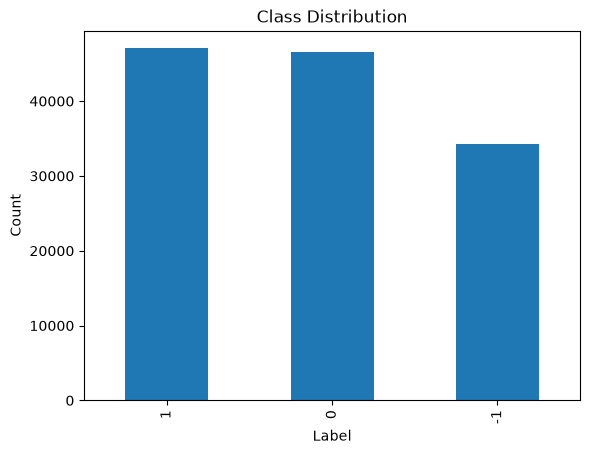

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [9]:
df.describe()

,label
count,127891.000000
mean,0.099772
std,0.791181
min,-1.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

792.0091209411621 MB


In [11]:
print(df.columns.tolist())

['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories']


In [12]:
numeric_cols = df.select_dtypes(include="number").columns
print(numeric_cols)

Index(['label'], dtype='str')


In [13]:
for col in df.columns:
    print(col)

sha256
md5
appeared
label
avclass
histogram
byteentropy
strings
general
header
section
imports
exports
datadirectories


In [14]:
import pandas as pd
import os

os.makedirs("../reports/summaries", exist_ok=True)

summary = pd.DataFrame({
    "Dataset": ["train_features_2"],
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate SHA256": [df["sha256"].duplicated().sum()],
    "Memory (MB)": [round(df.memory_usage(deep=True).sum()/(1024**2), 2)],
    "Malware Samples": [(df["label"] == 1).sum()],
    "Benign Samples": [(df["label"] == 0).sum()],
    "Unknown Samples": [(df["label"] == -1).sum()]
})

summary.to_csv("../reports/summaries/train_2_summary.csv", index=False)

print("Summary Saved!")

Summary Saved!
